#Model 1A: Gravity only simulation
#Gravity only, no drag, no spin, no swing

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
#Simulation #1: Basic simulation with only gravity. No drag, spin or bounce yet.

#Initial conditions:
X0 = 0
Y0 = 2.0
v0 = 30.0
theta_deg = -5.0
g = 9.80
dt = 0.001

#X0 is set to zero as the release point of the bowler is considered to be the
#start point. Y0 is set to 2.0 m to account for the height that the bowlers arm
#reaches as they are about to release the ball. V0 is the initial velocity which
#is the pace of the bowler. Initial angle is negative since the bowler bowls
#downward toward the pitch. g is the acceleration due to gravity and dt is the
#time step we are using.

#Initial values setup
theta = np.radians(theta_deg) #Degrees to radians
vx = v0*np.cos(theta)         #Initial X - velocity
vy = v0*np.sin(theta)         #Initial Y - velocity

x = X0
y = Y0    #The three initial conditions
t = 0

#List of values
x_value = [X0]
y_value = [Y0]
t_value = [0]

#Simulation
while y > 0:
  x = x + vx*dt   #Updating position
  y = y + vy*dt

  vy = vy - g*dt     #Changing Y-velocity
  t = t + dt         #Changing time

#Storing values in list
  x_value.append(x)
  y_value.append(y)
  t_value.append(t)

#Displaying results
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Distance traveled: {x:.2f} meters")

Time until ball reaches pitch: 0.43 seconds
Distance traveled: 12.73 meters


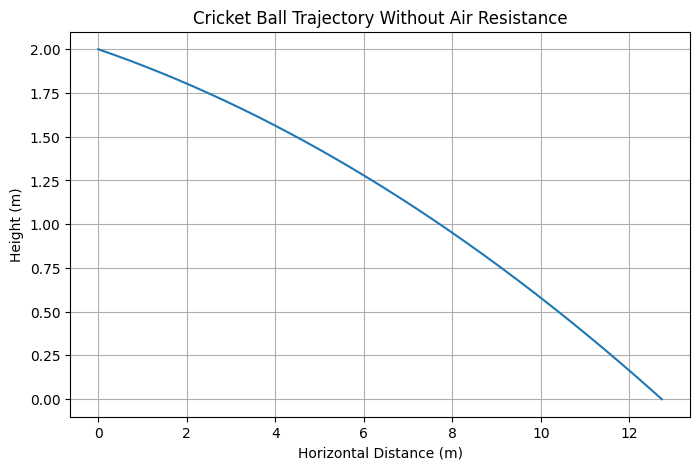

In [31]:
#Plot generation
import os
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(x_value, y_value)

plt.title("Cricket Ball Trajectory Without Air Resistance")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.savefig("figures/basic_projectile_motion.png", dpi=300, bbox_inches="tight")
plt.show()

## Model 1A Summary

This first model simulates the motion of a cricket ball under gravity only. The model ignores air resistance, swing, spin, and bounce. The purpose is to create a trajectory that later models can be compared against.

Key assumptions:
- The ball is treated as a point mass.
- Gravity is constant.
- There is no air resistance.
- There is no spin or swing.
- The simulation stops when the ball reaches the pitch.

In [32]:
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Time until ball reaches pitch: 0.43 seconds
Horizontal distance traveled: 12.73 meters


#Model 1B: Simple bounce model
#Gravity only, no drag, no spin, no swing

In [33]:
#Model 1B: Simple bounce

# Initial conditions
x = X0
y = Y0
t = 0

e = 0.6  # coefficient of restitution

theta = np.radians(theta_deg)

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

# Lists to store position and time
x_bounce_values = [x]
y_bounce_values = [y]
t_bounce_values = [t]

# Track whether the ball has bounced
has_bounced = False

while True:
    # Update position
    x = x + vx * dt
    y = y + vy * dt

    # Update vertical velocity due to gravity
    vy = vy - g * dt

    # Update time
    t = t + dt

    # First pitch contact: bounce
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        x_bounce_values.append(x)
        y_bounce_values.append(y)
        t_bounce_values.append(t)
        break

    # Store values
    x_bounce_values.append(x)
    y_bounce_values.append(y)
    t_bounce_values.append(t)

print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Coefficient of restitution: {e}")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Coefficient of restitution: 0.6
Final simulation time: 1.26 seconds
Horizontal distance traveled: 37.63 meters


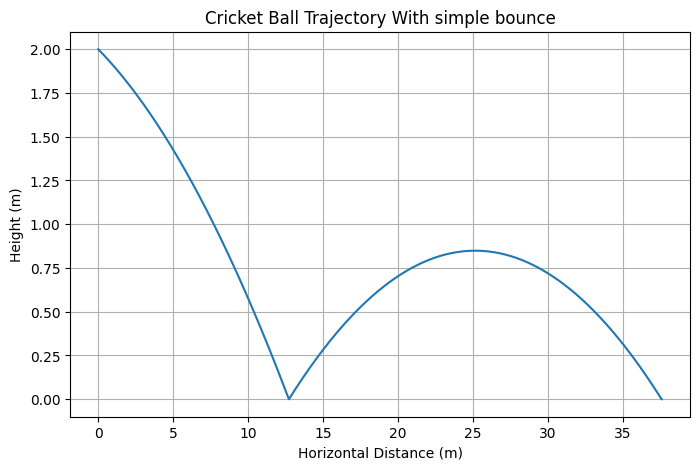

In [34]:
#Plot generation
import os
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(x_bounce_values, y_bounce_values)

plt.title("Cricket Ball Trajectory With simple bounce")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.savefig("figures/basic_bounce_motion.png", dpi=300, bbox_inches="tight")
plt.show()

## Model 1B Summary

This first model simulates the motion of a cricket ball under gravity only including simple bounce. The model ignores air resistance, swing, spin. The purpose is to create a trajectory that later models can be compared against.

Key assumptions:
- The ball is treated as a point mass.
- Gravity is constant.
- There is no air resistance.
- There is no spin or swing.
- The simulation stops before second contact with the pitch.

In [35]:
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")
print(f"Coefficient of restitution: {e}")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Time until ball reaches pitch: 1.26 seconds
Horizontal distance traveled: 37.63 meters
Coefficient of restitution: 0.6


# **Model** 2A: Projectile motion with air resistance

Gravity and air resistance only

In [36]:
# Model 2 constants

m = 0.156       # mass of cricket ball, kg
rho = 1.225     # air density, kg/m^3
Cd = 0.5        # drag coefficient, simplified assumption from NASA
r = 0.036       # radius of cricket ball, meters

A = np.pi * r**2  # cross-sectional area

In [37]:
#Initial conditions
x = X0
y = Y0
t = 0

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)
v = np.sqrt(vx**2 + vy**2)


#List of values
x_drag_value = [X0]
y_drag_value = [Y0]
t_drag_value = [0]

#Drag Force
F_drag = -0.5*rho*Cd*A*v**2
F_drag_x = F_drag*vx/v
F_drag_y = F_drag*vy/v

#Simulation
while y > 0:
  v = np.sqrt(vx**2 + vy**2)

  F_drag = -0.5*rho*Cd*A*v**2
  F_drag_x = F_drag*vx/v
  F_drag_y = F_drag*vy/v

  vx = vx + F_drag_x*dt/m    #Updating velocity
  vy = vy + (-g+F_drag_y/m)*dt

  x = x + vx*dt   #Updating position
  y = y + vy*dt

  t = t + dt         #Changing time

#Storing values in list
  x_drag_value.append(x)
  y_drag_value.append(y)
  t_drag_value.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag: {x:.2f} meters")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag: 0.44 seconds
Horizontal distance traveled with drag: 12.47 meters


Model 2A Plot

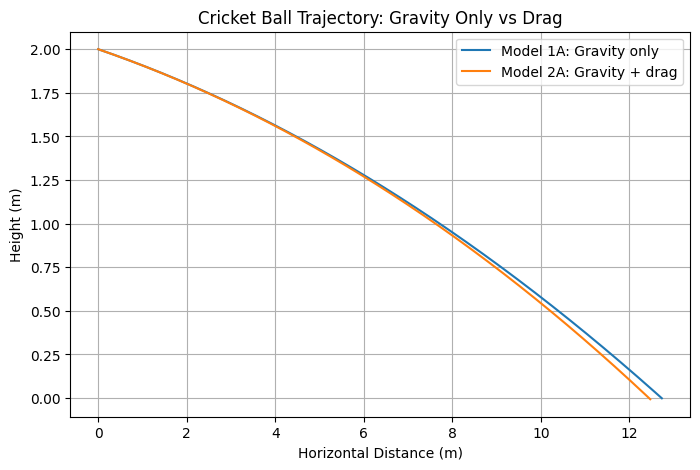

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(x_value, y_value, label="Model 1A: Gravity only")
plt.plot(x_drag_value, y_drag_value, label="Model 2A: Gravity + drag")

plt.title("Cricket Ball Trajectory: Gravity Only vs Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.legend()

plt.savefig("figures/projectile_motion_with_drag.png", dpi=300, bbox_inches="tight")

plt.show()

## Model 2A Summary
This second model simulates the motion of a cricket ball under gravity and drag.The model ignores swing, spin, and bounce. The purpose is to create a trajectory that can be compared with the baseline model

Key assumptions:

The ball is treated as a point mass.
Gravity is constant.
There is air resistance.
There is no spin or swing.
The simulation stops before contact with the pitch.

**Model** 2B: Projectile motion with air resistance

Gravity, air resistance and bounce

In [39]:
#Initial conditions
x = X0
y = Y0
t = 0

e = 0.6  # coefficient of restitution

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)

#List of values
x_drag_bounce_value = [X0]
y_drag_bounce_value = [Y0]
t_drag_bounce_value = [0]

# Track whether the ball has bounced
has_bounced = False

while True:
    x = x + vx*dt   #Updating position
    y = y + vy*dt

    v = np.sqrt(vx**2 + vy**2)

    F_drag = -0.5*rho*Cd*A*v**2     #Drag force
    F_drag_x = F_drag*vx/v if v != 0 else 0
    F_drag_y = F_drag*vy/v if v != 0 else 0

    vx = vx + F_drag_x*dt/m    #Updating velocity
    vy = vy + (-g+F_drag_y/m)*dt


    t = t + dt      #Changing time

    # First pitch contact: bounce
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        x_drag_bounce_value.append(x)
        y_drag_bounce_value.append(y)
        t_drag_bounce_value.append(t)
        break

    # Storing values in list
    x_drag_bounce_value.append(x)
    y_drag_bounce_value.append(y)
    t_drag_bounce_value.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag and bounce: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag and bounce: {x:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag and bounce: 1.21 seconds
Horizontal distance traveled with drag and bounce: 31.73 meters


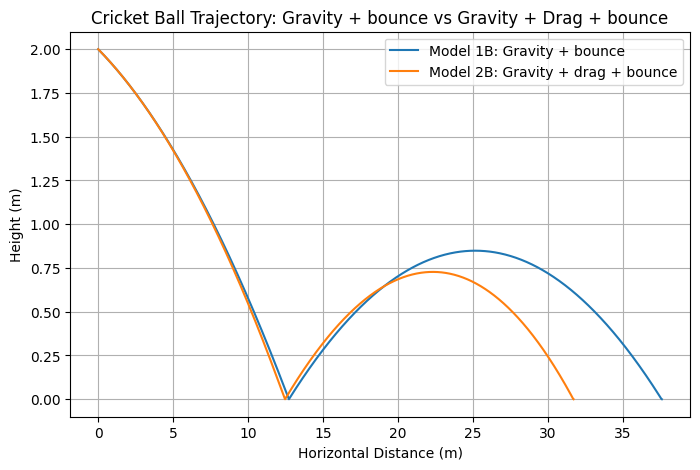

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(x_bounce_values, y_bounce_values, label="Model 1B: Gravity + bounce")
plt.plot(x_drag_bounce_value, y_drag_bounce_value, label="Model 2B: Gravity + drag + bounce")

plt.title("Cricket Ball Trajectory: Gravity + bounce vs Gravity + Drag + bounce")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.legend()

plt.savefig("figures/projectile_motion_with_drag_plus_bounce.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Model 2B Summary**
This second model simulates the motion of a cricket ball under gravity and drag including simple bounce. The model ignores swing, and spin. The purpose is to create a trajectory that can be compared with model 1B.

Key assumptions:

The ball is treated as a point mass.
Gravity is constant.
There is air resistance.
There is no spin or swing.
The simulation stops before second contact with the pitch.

# **Model** 3A: Aerodynamic effects



In [42]:
# Model # constants

m = 0.156       # mass of cricket ball, kg
rho = 1.225     # air density, kg/m^3
Cd = 0.5        # drag coefficient, simplified assumption from NASA
r = 0.036       # radius of cricket ball, meters
Cs = 0.30       # swing coefficient

A = np.pi * r**2  # cross-sectional area

In [43]:
#Initial conditions
x = X0
y = Y0
z = 0
t = 0

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)
vz = 0
v = np.sqrt(vx**2 + vy**2 + vz**2)


#List of values
x_swing_values = [x]
y_swing_values = [y]
z_swing_values = [z]
t_swing_values = [0]

t = 0

#Swing Force
F_swing = 0.5*rho*Cs*A*v**2      #Only acts in the Z direction


#Drag Force
F_drag = -0.5*rho*Cd*A*v**2
F_drag_x = F_drag*vx/v
F_drag_y = F_drag*vy/v
F_drag_z = F_drag*vz/v

#Simulation
while y > 0:
  v = np.sqrt(vx**2 + vy**2 + vz**2)

  F_swing_z = 0.5*rho*Cs*A*v**2

  F_drag = -0.5*rho*Cd*A*v**2
  F_drag_x = F_drag*vx/v
  F_drag_y = F_drag*vy/v
  F_drag_z = F_drag*vz/v


  vx = vx + F_drag_x*dt/m    #Updating velocity
  vy = vy + (-g+F_drag_y/m)*dt
  vz = vz + (F_drag_z + F_swing_z) * dt / m

  x = x + vx*dt   #Updating position
  y = y + vy*dt
  z = z + vz*dt

  t = t + dt         #Changing time

#Storing values in list
  x_swing_values.append(x)
  y_swing_values.append(y)
  z_swing_values.append(z)
  t_swing_values.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag and swing: {x:.2f} meters")
print(f"Sideways distance traveled due to swing: {z:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag: 0.44 seconds
Horizontal distance traveled with drag and swing: 12.47 meters
Sideways distance traveled due to swing: 0.38 meters


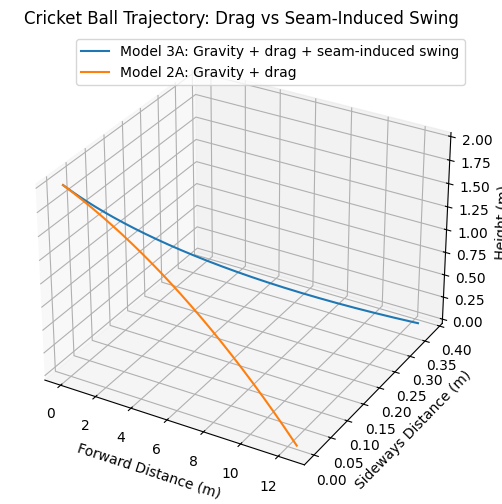

In [44]:
# 3D comparison plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Model 3A: gravity + drag + swing
ax.plot(
    x_swing_values,
    z_swing_values,
    y_swing_values,
    label="Model 3A: Gravity + drag + seam-induced swing"
)

# Model 2A: no sideways motion, so z = 0
ax.plot(
    x_drag_value,
    np.zeros(len(x_drag_value)),
    y_drag_value,
    label="Model 2A: Gravity + drag"
)

ax.set_title("Cricket Ball Trajectory: Drag vs Seam-Induced Swing")

ax.set_xlabel("Forward Distance (m)")
ax.set_ylabel("Sideways Distance (m)")        #y-axis as sideways distance aids in visulaization.
ax.set_zlabel("Height (m)")

ax.legend()

plt.savefig(
    "figures/projectile_motion_with_swing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##**Model 3A Summary**
This third model simulates the motion of a cricket ball under gravity, drag, and seam-induced swing. The model ignores bounce and spin. The purpose is to create a trajectory that can be compared with model 2A.

Key assumptions:

The ball is treated as a point mass.
Gravity is constant.
There is air resistance.
There is swing.italicized text
There is no spin.
The simulation stops before second contact with the pitch.





# **Model** 3B: Aerodynamic effects and bounce



In [45]:
#Initial conditions
x = X0
y = Y0
z = 0
t = 0

e = 0.6  # coefficient of restitution

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)
vz = 0

#List of values
x_swing_bounce_values = [X0]
y_swing_bounce_values = [Y0]
z_swing_bounce_values = [0]
t_swing_bounce_values = [0]

# Track whether the ball has bounced
has_bounced = False

while True:
    x = x + vx*dt   #Updating position
    y = y + vy*dt
    z = z + vz*dt

    v = np.sqrt(vx**2 + vy**2 + vz**2)

    F_swing_z = 0.5*rho*Cs*A*v**2      #Only acts in the Z direction

    F_drag

    F_drag = -0.5*rho*Cd*A*v**2     #Drag force
    F_drag_x = F_drag*vx/v if v != 0 else 0
    F_drag_y = F_drag*vy/v if v != 0 else 0
    F_drag_z = F_drag*vz/v if v != 0 else 0

    vx = vx + F_drag_x*dt/m    #Updating velocity
    vy = vy + (-g+F_drag_y/m)*dt
    vz = vz + (F_drag_z + F_swing_z) * dt / m


    t = t + dt      #Changing time

    # First pitch contact: bounce
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        x_swing_bounce_values.append(x)
        y_swing_bounce_values.append(y)
        z_swing_bounce_values.append(z)
        t_swing_bounce_values.append(t)
        break

    # Storing values in list
    x_swing_bounce_values.append(x)
    y_swing_bounce_values.append(y)
    z_swing_bounce_values.append(z)
    t_swing_bounce_values.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag, aerodynamic effects, and bounce: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag, aerodynamic effects, and bounce: {x:.2f} meters")
print(f"Sideways distance traveled with drag, aerodynamic effects, and bounce: {z:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag, aerodynamic effects, and bounce: 1.21 seconds
Horizontal distance traveled with drag, aerodynamic effects, and bounce: 31.73 meters
Sideways distance traveled with drag, aerodynamic effects, and bounce: 2.47 meters


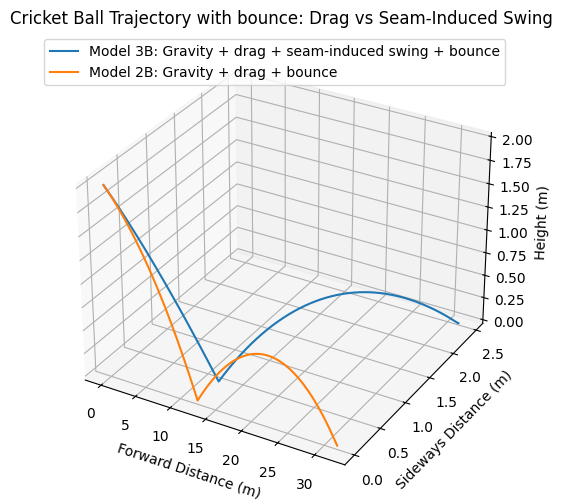

In [46]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Model 3B: gravity + drag + swing + bounce
ax.plot(
    x_swing_bounce_values,
    z_swing_bounce_values,
    y_swing_bounce_values,
    label="Model 3B: Gravity + drag + seam-induced swing + bounce"
)

# Model 2B: no sideways motion, so z = 0
ax.plot(
    x_drag_bounce_value,
    np.zeros(len(x_drag_bounce_value)),
    y_drag_bounce_value,
    label="Model 2B: Gravity + drag + bounce"
)

ax.set_title("Cricket Ball Trajectory with bounce: Drag vs Seam-Induced Swing")

ax.set_xlabel("Forward Distance (m)")
ax.set_ylabel("Sideways Distance (m)")        #y-axis as sideways distance aids in visulaization.
ax.set_zlabel("Height (m)")

ax.legend()

plt.savefig(
    "figures/projectile_motion_with_swing_bounce.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##**Model 3B Summary**
This third model simulates the motion of a cricket ball under gravity, drag, and seam-induced swing. The model includes bounce and ignores spin. The purpose is to create a trajectory that can be compared with model 2B.

Key assumptions:

The ball is treated as a point mass.
Gravity is constant.
There is air resistance.
There is swing.italicized text
There is no spin.
The simulation stops before second contact with the pitch.



# **Model** 4A: Magnus effect

In [47]:
# Model 4A constants and initial conditions

m = 0.156
rho = 1.225
Cd = 0.50
Cm = 0.18

r = 0.036
A = np.pi * r**2

g = 9.81
dt = 0.001

# Spin-bowling baseline
v0_spin = 22.0
theta_spin_deg = -5.0
theta_spin = np.radians(theta_spin_deg)

x0_spin = 0
y0_spin = 2.0
z0_spin = 0

# Angular velocity vector in our coordinate system
omega = np.array([161.64, 37.67, -59.14])

In [48]:
# Model 4A Baseline Simulation (Gravity + Drag only)
# Using spin bowling parameters for comparison with Magnus effect
x = x0_spin
y = y0_spin
z = z0_spin
t = 0

vx = v0_spin * np.cos(theta_spin)
vy = v0_spin * np.sin(theta_spin)
vz = 0 # No initial sideways velocity for this baseline

# Lists of values for no Magnus effect
x_no_magnus_values = [x]
y_no_magnus_values = [y]
z_no_magnus_values = [z]
t_no_magnus_values = [0]

# Simulation loop
while y > 0:
    v = np.sqrt(vx**2 + vy**2 + vz**2)

    # Drag force
    F_drag = -0.5 * rho * Cd * A * v**2
    F_drag_x = F_drag * vx / v if v != 0 else 0
    F_drag_y = F_drag * vy / v if v != 0 else 0
    F_drag_z = F_drag * vz / v if v != 0 else 0

    # Updating velocity (Gravity + Drag only)
    vx = vx + F_drag_x * dt / m
    vy = vy + (-g + F_drag_y / m) * dt
    vz = vz + F_drag_z * dt / m

    # Updating position
    x = x + vx * dt
    y = y + vy * dt
    z = z + vz * dt
    t = t + dt

    # Storing values
    x_no_magnus_values.append(x)
    y_no_magnus_values.append(y)
    z_no_magnus_values.append(z)
    t_no_magnus_values.append(t)

print(f"Model 4A Baseline (Gravity + Drag only) Simulation Results:")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Forward distance traveled: {x:.2f} meters")
print(f"Sideways distance traveled: {z:.2f} meters")

Model 4A Baseline (Gravity + Drag only) Simulation Results:
Final simulation time: 0.48 seconds
Forward distance traveled: 10.15 meters
Sideways distance traveled: 0.00 meters


In [49]:
# Model 4A Simulation (Gravity + Drag + Magnus)
# Using spin bowling parameters
x = x0_spin
y = y0_spin
z = z0_spin
t = 0

vx = v0_spin * np.cos(theta_spin)
vy = v0_spin * np.sin(theta_spin)
vz = 0 # Initial sideways velocity

# Lists of values for Magnus effect
x_magnus_values = [x]
y_magnus_values = [y]
z_magnus_values = [z]
t_magnus_values = [0]

# Simulation loop
while y > 0:
    v = np.sqrt(vx**2 + vy**2 + vz**2)

    # Drag force
    F_drag = -0.5 * rho * Cd * A * v**2
    F_drag_x = F_drag * vx / v if v != 0 else 0
    F_drag_y = F_drag * vy / v if v != 0 else 0
    F_drag_z = F_drag * vz / v if v != 0 else 0

    # Magnus force calculation (as fixed previously)
    velocity = np.array([vx, vy, vz])
    omega_cross_v = np.cross(omega, velocity)
    cross_magnitude = np.linalg.norm(omega_cross_v)
    F_magnus = 0.5 * rho * Cm * A * v**2

    if cross_magnitude > 0:
        F_magnus_vector = F_magnus * (omega_cross_v / cross_magnitude)
    else:
        F_magnus_vector = np.array([0.0, 0.0, 0.0])

    # Updating velocity (Gravity + Drag + Magnus)
    vx = vx + (F_drag_x + F_magnus_vector[0]) * dt / m
    vy = vy + (-g + F_drag_y / m + F_magnus_vector[1] / m) * dt
    vz = vz + (F_drag_z + F_magnus_vector[2]) * dt / m

    # Updating position
    x = x + vx * dt
    y = y + vy * dt
    z = z + vz * dt
    t = t + dt

    # Storing values
    x_magnus_values.append(x)
    y_magnus_values.append(y)
    z_magnus_values.append(z)
    t_magnus_values.append(t)

print(f"Model 4A (Gravity + Drag + Magnus) Simulation Results:")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Forward distance traveled: {x:.2f} meters")
print(f"Sideways distance traveled: {z:.2f} meters")

Model 4A (Gravity + Drag + Magnus) Simulation Results:
Final simulation time: 0.47 seconds
Forward distance traveled: 9.84 meters
Sideways distance traveled: -0.11 meters


In [50]:
    # Magnus force


    velocity = np.array([vx, vy, vz])

    omega_cross_v = np.cross(omega, velocity)

    cross_magnitude = np.linalg.norm(omega_cross_v)

    F_magnus = 0.5 * rho * Cm * A * v**2

    # Calculate F_magnus_vector based on F_magnus and omega_cross_v
    if cross_magnitude > 0:
        F_magnus_vector = F_magnus * (omega_cross_v / cross_magnitude)
    else:
        F_magnus_vector = np.array([0.0, 0.0, 0.0])


    # Updating velocity


    vx = vx + (
        F_drag_x + F_magnus_vector[0]
    ) * dt / m

    vy = vy + (
        -g
        + (F_drag_y + F_magnus_vector[1]) / m
    ) * dt

    vz = vz + (
        F_drag_z + F_magnus_vector[2]
    ) * dt / m

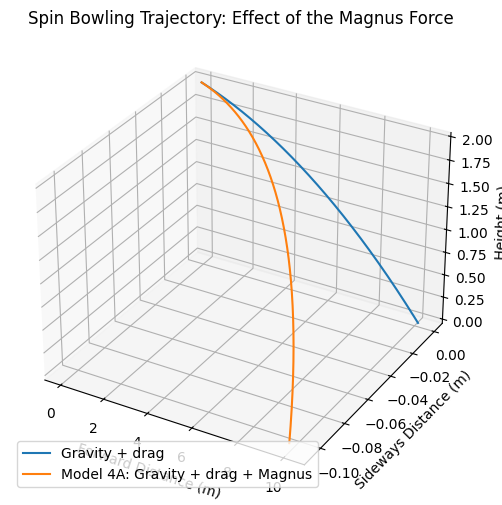

In [51]:
# 3D comparison plot for Model 4A

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Baseline spin-bowling trajectory: gravity + drag only
ax.plot(
    x_no_magnus_values,
    z_no_magnus_values,
    y_no_magnus_values,
    label="Gravity + drag"
)

# Model 4A: gravity + drag + Magnus
ax.plot(
    x_magnus_values,
    z_magnus_values,
    y_magnus_values,
    label="Model 4A: Gravity + drag + Magnus"
)

ax.set_title("Spin Bowling Trajectory: Effect of the Magnus Force")

ax.set_xlabel("Forward Distance (m)")
ax.set_ylabel("Sideways Distance (m)")
ax.set_zlabel("Height (m)")

ax.legend()

plt.savefig(
    "figures/spin_bowling_magnus.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##**Model 4A Summary**
This fourth model simulates the motion of a cricket ball under gravity, drag, and the Magnus effect. The model ignores bounce. The purpose is to create a trajectory that can be compared with model 3A.

Key assumptions:

The translational motion of the ball is tracked through its center of mass.
Gravity is constant.
There is air resistance.
There is Magnus force
The simulation stops before contact with the pitch.

# **Model** 4B: Magnus effect and bounce

In [52]:
# Model 4B constants and initial conditions

m = 0.156
rho = 1.225
Cd = 0.50
Cm = 0.18

r = 0.036
A = np.pi * r**2

g = 9.81
dt = 0.001

# Spin-bowling baseline
v0_spin = 22.0
theta_spin_deg = -5.0
theta_spin = np.radians(theta_spin_deg)

x0_spin = 0
y0_spin = 2.0
z0_spin = 0

# Angular velocity vector in our coordinate system
omega = np.array([161.64, 37.67, -59.14])

# Bounce condition
e = 0.60
mu = 0.30

turn_direction = 1

In [53]:
# Model 4B Baseline Simulation (Magnus + bounce, no pitch friction)
# Initial conditions for Model 4B
x = x0_spin
y = y0_spin
z = z0_spin
t = 0

vx = v0_spin * np.cos(theta_spin)
vy = v0_spin * np.sin(theta_spin)
vz = 0 # Initial sideways velocity

# Lists to store values for no pitch friction
x_no_friction_values = [x]
y_no_friction_values = [y]
z_no_friction_values = [z]
t_no_friction_values = [t]

has_bounced = False

while True:
    v = np.sqrt(vx**2 + vy**2 + vz**2)

    # Drag force
    F_drag = -0.5 * rho * Cd * A * v**2
    F_drag_x = F_drag * vx / v if v != 0 else 0
    F_drag_y = F_drag * vy / v if v != 0 else 0
    F_drag_z = F_drag * vz / v if v != 0 else 0

    # Magnus force
    velocity = np.array([vx, vy, vz])
    omega_cross_v = np.cross(omega, velocity)
    cross_magnitude = np.linalg.norm(omega_cross_v)
    F_magnus = 0.5 * rho * Cm * A * v**2

    if cross_magnitude > 0:
        F_magnus_vector = F_magnus * (omega_cross_v / cross_magnitude)
    else:
        F_magnus_vector = np.array([0.0, 0.0, 0.0])

    # Updating velocity
    vx = vx + (F_drag_x + F_magnus_vector[0]) * dt / m
    vy = vy + (-g + F_drag_y / m + F_magnus_vector[1] / m) * dt
    vz = vz + (F_drag_z + F_magnus_vector[2]) * dt / m

    # Updating position
    x = x + vx * dt
    y = y + vy * dt
    z = z + vz * dt
    t = t + dt

    # First pitch contact: bounce (no friction)
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        # Append final point before breaking
        x_no_friction_values.append(x)
        y_no_friction_values.append(y)
        z_no_friction_values.append(z)
        t_no_friction_values.append(t)
        break

    # Storing values
    x_no_friction_values.append(x)
    y_no_friction_values.append(y)
    z_no_friction_values.append(z)
    t_no_friction_values.append(t)

print(f"Model 4B Baseline (Magnus + bounce, no pitch friction) Simulation Results:")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Forward distance traveled: {x:.2f} meters")
print(f"Sideways distance traveled: {z:.2f} meters")

Model 4B Baseline (Magnus + bounce, no pitch friction) Simulation Results:
Final simulation time: 1.18 seconds
Forward distance traveled: 23.48 meters
Sideways distance traveled: -0.52 meters


In [54]:
# Model 4B Full Simulation (Magnus + bounce + pitch friction)
# Initial conditions for Model 4B
x = x0_spin
y = y0_spin
z = z0_spin
t = 0

vx = v0_spin * np.cos(theta_spin)
vy = v0_spin * np.sin(theta_spin)
vz = 0 # Initial sideways velocity

# Lists to store values for full Model 4B
x_magnus_bounce_values = [x]
y_magnus_bounce_values = [y]
z_magnus_bounce_values = [z]
t_magnus_bounce_values = [t]

has_bounced = False

while True:
    v = np.sqrt(vx**2 + vy**2 + vz**2)

    # Drag force
    F_drag = -0.5 * rho * Cd * A * v**2
    F_drag_x = F_drag * vx / v if v != 0 else 0
    F_drag_y = F_drag * vy / v if v != 0 else 0
    F_drag_z = F_drag * vz / v if v != 0 else 0

    # Magnus force
    velocity = np.array([vx, vy, vz])
    omega_cross_v = np.cross(omega, velocity)
    cross_magnitude = np.linalg.norm(omega_cross_v)
    F_magnus = 0.5 * rho * Cm * A * v**2

    if cross_magnitude > 0:
        F_magnus_vector = F_magnus * (omega_cross_v / cross_magnitude)
    else:
        F_magnus_vector = np.array([0.0, 0.0, 0.0])

    # Updating velocity
    vx = vx + (F_drag_x + F_magnus_vector[0]) * dt / m
    vy = vy + (-g + F_drag_y / m + F_magnus_vector[1] / m) * dt
    vz = vz + (F_drag_z + F_magnus_vector[2]) * dt / m

    # Updating position
    x = x + vx * dt
    y = y + vy * dt
    z = z + vz * dt
    t = t + dt

    # First pitch contact: bounce with friction
    if y <= 0 and not has_bounced:
        y = 0
        vy_before = vy # Save incoming vertical velocity
        vy = -e * vy_before # Apply vertical bounce

        J_n = m * (1 + e) * abs(vy_before) # Normal impulse
        J_f = mu * J_n # Frictional impulse
        vz = vz + turn_direction * J_f / m # Simplified friction-induced turn

        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        # Append final point before breaking
        x_magnus_bounce_values.append(x)
        y_magnus_bounce_values.append(y)
        z_magnus_bounce_values.append(z)
        t_magnus_bounce_values.append(t)
        break

    # Storing values
    x_magnus_bounce_values.append(x)
    y_magnus_bounce_values.append(y)
    z_magnus_bounce_values.append(z)
    t_magnus_bounce_values.append(t)

print(f"Model 4B (Magnus + bounce + pitch friction) Simulation Results:")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Forward distance traveled: {x:.2f} meters")
print(f"Sideways distance traveled: {z:.2f} meters")

Model 4B (Magnus + bounce + pitch friction) Simulation Results:
Final simulation time: 1.18 seconds
Forward distance traveled: 23.41 meters
Sideways distance traveled: 1.62 meters


In [55]:
  # Magnus force


  velocity = np.array([vx, vy, vz])

  omega_cross_v = np.cross(omega, velocity)

  cross_magnitude = np.linalg.norm(omega_cross_v)

  F_magnus = 0.5 * rho * Cm * A * v**2

  # Calculate F_magnus_vector based on F_magnus and omega_cross_v
  if cross_magnitude > 0:
      F_magnus_vector = F_magnus * (omega_cross_v / cross_magnitude)
  else:
      F_magnus_vector = np.array([0.0, 0.0, 0.0])



  # Updating velocity


  vx = vx + (
      F_drag_x + F_magnus_vector[0]
  ) * dt / m

  vy = vy + (
      -g
      + (F_drag_y + F_magnus_vector[1]) / m
  ) * dt

  vz = vz + (
      F_drag_z + F_magnus_vector[2]
  ) * dt / m

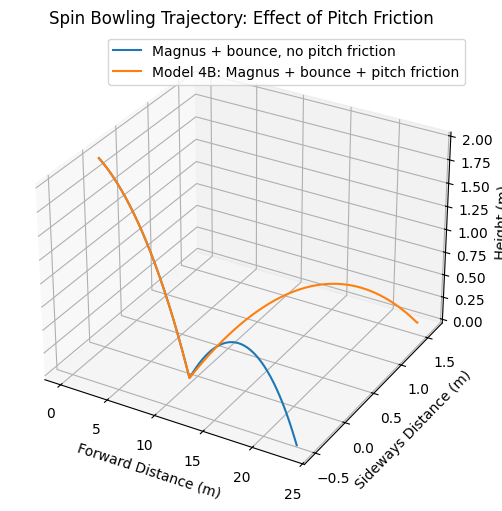

In [56]:
# 3D comparison plot for Model 4B

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Magnus + bounce, but no pitch friction
ax.plot(
    x_no_friction_values,
    z_no_friction_values,
    y_no_friction_values,
    label="Magnus + bounce, no pitch friction"
)

# Full Model 4B
ax.plot(
    x_magnus_bounce_values,
    z_magnus_bounce_values,
    y_magnus_bounce_values,
    label="Model 4B: Magnus + bounce + pitch friction"
)

ax.set_title("Spin Bowling Trajectory: Effect of Pitch Friction")

ax.set_xlabel("Forward Distance (m)")
ax.set_ylabel("Sideways Distance (m)")
ax.set_zlabel("Height (m)")

ax.legend()

plt.savefig(
    "figures/spin_bowling_friction_bounce.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##**Model 4B Summary**
This fourth model simulates the motion of a cricket ball under gravity, drag, and the Magnus effect. The model includes bounce. The purpose is to create a trajectory that can be compared with model 3B.

Key assumptions:

The translational motion of the ball is tracked through its center of mass.
Gravity is constant.
There is air resistance.
There is Magnus force
The simulation stops before second contact with the pitch.